# Star-Galaxy Classification using XGBoost

## Setup and Initialization

In [5]:
import sys
import subprocess

is_venv = hasattr(sys, 'real_prefix') or (hasattr(sys, 'base_prefix') and sys.base_prefix != sys.prefix)
if not is_venv:
    print("WARNING: You are running the notebook outside of a virtual environment (venv)!")
    print("This can cause package conflicts or require system package overrides.")
    print("To fix this, please select the 'venv' kernel in your Jupyter environment.\n")

pip_args = [
    sys.executable, "-m", "pip", "install", "xgboost", "scikit-learn", "pandas",
    "numpy<2", "matplotlib", "seaborn", "joblib",
    "astroquery", "requests", "shap", "numba", "coverage>=7.6.0", "--upgrade"
]

if not is_venv:
    pip_args.append("--break-system-packages")

print(f"Installing packages using: {' '.join(pip_args)}")
subprocess.run(pip_args, check=True)

Installing packages using: /home/nevilcp/Desktop/Projects/dsa_project/.venv/bin/python -m pip install xgboost scikit-learn pandas numpy<2 matplotlib seaborn joblib astroquery requests shap numba coverage>=7.6.0 --upgrade
  Using cached shap-0.51.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (25 kB)
INFO: pip is looking at multiple versions of shap to determine which version is compatible with other requirements. This could take a while.
  Using cached shap-0.50.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (25 kB)


CompletedProcess(args=['/home/nevilcp/Desktop/Projects/dsa_project/.venv/bin/python', '-m', 'pip', 'install', 'xgboost', 'scikit-learn', 'pandas', 'numpy<2', 'matplotlib', 'seaborn', 'joblib', 'astroquery', 'requests', 'shap', 'numba', 'coverage>=7.6.0', '--upgrade'], returncode=0)

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os
import joblib
import json
import itertools
import time

import shap
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.calibration import CalibrationDisplay

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

os.makedirs("models",  exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

print("Environment ready.")

Environment ready.


## Data Loading

In [7]:
# CasJobs query (Sevilla-Noarbe 2015)
CASJOBS_QUERY = """
SELECT
    p.ra, p.dec,
    p.petromag_u, p.petromag_g, p.petromag_r, p.petromag_i, p.petromag_z,
    p.modelmag_u, p.modelmag_g, p.modelmag_r, p.modelmag_i, p.modelmag_z,
    p.psfmag_u,   p.psfmag_g,   p.psfmag_r,   p.psfmag_i,   p.psfmag_z,
    p.fibermag_u, p.fibermag_g, p.fibermag_r, p.fibermag_i, p.fibermag_z,
    p.petrorad_r, p.petror50_r, p.petror90_r,
    p.lnlstar_r,  p.lnlexp_r,   p.lnldev_r,
    p.me1_r,      p.me2_r,      p.mrrcc_r,
    p.type,
    s.class
INTO mydb.SGtable
FROM dr9.PhotoPrimary AS p
JOIN dr9.SpecObj       AS s ON s.bestobjid = p.objid
WHERE p.modelmag_r BETWEEN 14.0 AND 23.0
"""
print(CASJOBS_QUERY)


SELECT
    p.ra, p.dec,
    p.petromag_u, p.petromag_g, p.petromag_r, p.petromag_i, p.petromag_z,
    p.modelmag_u, p.modelmag_g, p.modelmag_r, p.modelmag_i, p.modelmag_z,
    p.psfmag_u,   p.psfmag_g,   p.psfmag_r,   p.psfmag_i,   p.psfmag_z,
    p.fibermag_u, p.fibermag_g, p.fibermag_r, p.fibermag_i, p.fibermag_z,
    p.petrorad_r, p.petror50_r, p.petror90_r,
    p.lnlstar_r,  p.lnlexp_r,   p.lnldev_r,
    p.me1_r,      p.me2_r,      p.mrrcc_r,
    p.type,
    s.class
INTO mydb.SGtable
FROM dr9.PhotoPrimary AS p
JOIN dr9.SpecObj       AS s ON s.bestobjid = p.objid
WHERE p.modelmag_r BETWEEN 14.0 AND 23.0



In [8]:
DATA_PATH = "data/sdss_dr9_sg.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Total objects loaded : {len(df):,}")
print(f"Expected (paper)     : 2,195,172  (±1 row is negligible)")
print(f"Columns              : {list(df.columns)}")
print(f"\nRaw class distribution (before QSO exclusion):")
print(df["class"].value_counts())

Total objects loaded : 2,195,173
Expected (paper)     : 2,195,172  (±1 row is negligible)
Columns              : ['ra', 'dec', 'petromag_u', 'petromag_g', 'petromag_r', 'petromag_i', 'petromag_z', 'modelmag_u', 'modelmag_g', 'modelmag_r', 'modelmag_i', 'modelmag_z', 'psfmag_u', 'psfmag_g', 'psfmag_r', 'psfmag_i', 'psfmag_z', 'fibermag_u', 'fibermag_g', 'fibermag_r', 'fibermag_i', 'fibermag_z', 'petrorad_r', 'petror50_r', 'petror90_r', 'lnlstar_r', 'lnlexp_r', 'lnldev_r', 'me1_r', 'me2_r', 'mrrcc_r', 'type', 'class']

Raw class distribution (before QSO exclusion):
class
GALAXY    1338919
STAR       627166
QSO        229088
Name: count, dtype: int64


## Preprocessing
Filter out quasi-stellar objects (QSOs) and handle missing data sentinels.

QSOs excluded : 229,088  (not modelled — binary classification only)
Galaxies (label=1): 1,338,919
Stars    (label=0): 627,166


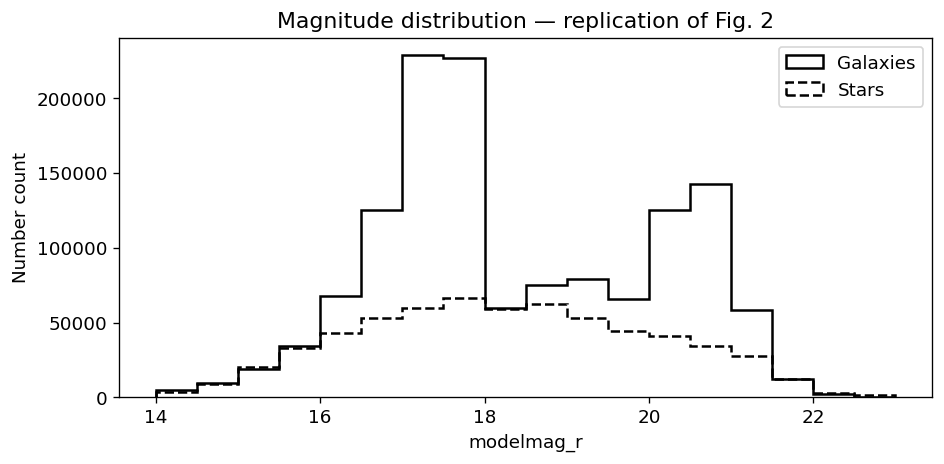

In [9]:
n_qso = (df["class"].str.upper() == "QSO").sum()
df = df[df["class"].str.upper() != "QSO"].copy()
print(f"QSOs excluded : {n_qso:,}  (not modelled — binary classification only)")

# Binary labels: galaxy=1, star=0
df["label"]     = (df["class"].str.upper() == "GALAXY").astype(int)
# SDSS photometric baseline: type==3 → galaxy
df["type_pred"] = (df["type"] == 3).astype(int)

print(f"Galaxies (label=1): {df['label'].sum():,}")
print(f"Stars    (label=0): {(df['label']==0).sum():,}")

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(14, 23.5, 0.5)
ax.hist(df.loc[df["label"]==1, "modelmag_r"], bins=bins, histtype="step",
        color="black", linewidth=1.5, label="Galaxies")
ax.hist(df.loc[df["label"]==0, "modelmag_r"], bins=bins, histtype="step",
        color="black", linewidth=1.5, linestyle="--", label="Stars")
ax.set_xlabel("modelmag_r")
ax.set_ylabel("Number count")
ax.set_title("Magnitude distribution — replication of Fig. 2")
ax.legend()
plt.tight_layout()
plt.savefig("figures/magnitude_distribution.png")
plt.show()

In [10]:
# Handle sentinels (-9999/9999)
SENTINEL_LOW  = -9999
SENTINEL_HIGH =  9999

before = len(df)
df.replace(SENTINEL_LOW,  np.nan, inplace=True)
df.replace(SENTINEL_HIGH, np.nan, inplace=True)
df.dropna(inplace=True)
after = len(df)

print(f"Rows before cleaning : {before:,}")
print(f"Rows after cleaning  : {after:,}")
print(f"Dropped              : {before - after:,}  ({100*(before-after)/before:.2f}%)")

Rows before cleaning : 1,966,085
Rows after cleaning  : 1,965,187
Dropped              : 898  (0.05%)


## Feature Engineering
Define shape features, color indices, and concentration parameters.

In [11]:
BANDS = ["u", "g", "r", "i", "z"]

SHAPE_FEATURES = [
    "petror50_r",  # radius containing 50% of Petrosian flux
    "petror90_r",  # radius containing 90% of Petrosian flux
    "lnlstar_r",   # log-likelihood of fit to PSF
    "lnlexp_r",    # log-likelihood of fit to exponential profile
    "lnldev_r",    # log-likelihood of fit to de Vaucouleurs profile
    "me1_r",       # ellipticity component 1
    "me2_r",       # ellipticity component 2
    "mrrcc_r",     # second moment of object brightness
]

MAG_FEATURES = (
    [f"fibermag_{b}" for b in BANDS] +
    [f"petromag_{b}" for b in BANDS] +
    [f"modelmag_{b}" for b in BANDS] +
    [f"psfmag_{b}"   for b in BANDS]
)

COLOR_FEATURES        = ["color_ug", "color_gr", "color_ri", "color_iz"]
CONCENTRATION_FEATURE = ["concentration"]

ALL_FEATURES = SHAPE_FEATURES + MAG_FEATURES + COLOR_FEATURES + CONCENTRATION_FEATURE

print(f"Shape features      : {len(SHAPE_FEATURES)}")
print(f"Magnitude features  : {len(MAG_FEATURES)}")
print(f"Color features      : {len(COLOR_FEATURES)}")
print(f"Concentration       : {len(CONCENTRATION_FEATURE)}")
print(f"Total features      : {len(ALL_FEATURES)}  (no duplicates)")
assert len(ALL_FEATURES) == len(set(ALL_FEATURES)), "Duplicate feature names detected!"
print("Duplicate check     : PASSED")

Shape features      : 8
Magnitude features  : 20
Color features      : 4
Concentration       : 1
Total features      : 33  (no duplicates)
Duplicate check     : PASSED


In [12]:
df["color_ug"]    = df["modelmag_u"] - df["modelmag_g"]
df["color_gr"]    = df["modelmag_g"] - df["modelmag_r"]
df["color_ri"]    = df["modelmag_r"] - df["modelmag_i"]
df["color_iz"]    = df["modelmag_i"] - df["modelmag_z"]

# Concentration = psfmag_r - modelmag_r
df["concentration"] = df["psfmag_r"] - df["modelmag_r"]

print("Derived columns added: color_ug, color_gr, color_ri, color_iz, concentration")
df[ALL_FEATURES].describe().round(3)

Derived columns added: color_ug, color_gr, color_ri, color_iz, concentration


,petror50_r,petror90_r,lnlstar_r,lnlexp_r,lnldev_r,me1_r,me2_r,mrrcc_r,fibermag_u,fibermag_g,...,psfmag_u,psfmag_g,psfmag_r,psfmag_i,psfmag_z,color_ug,color_gr,color_ri,color_iz,concentration
count,1965187.000,1965187.000,1965187.000,1965187.000,1965187.000,1965187.000,1965187.000,1965187.000,1965187.000,1965187.000,...,1965187.000,1965187.000,1965187.000,1965187.000,1965187.000,1965187.000,1965187.000,1965187.000,1965187.000,1965187.000
mean,1.648,4.181,-4162.530,-477.464,-240.267,-0.018,-0.003,20.529,21.806,20.309,...,21.765,20.245,19.270,18.762,18.428,1.740,1.028,0.522,0.294,0.920
std,1.628,3.570,9636.959,1769.181,846.322,2.006,3.617,227.360,1.910,1.886,...,2.030,1.955,1.643,1.464,1.408,0.934,0.598,0.418,0.323,0.812
min,0.034,0.054,-127670.500,-108972.500,-78394.420,-625.007,-142.076,-46790.360,11.918,13.546,...,12.517,10.817,12.740,8.370,10.260,-12.315,-9.350,-15.940,-14.755,-2.109
25%,0.714,1.585,-4623.366,-252.429,-115.777,-0.108,-0.094,3.804,20.564,19.083,...,20.466,19.003,18.253,17.878,17.556,1.164,0.577,0.285,0.156,0.017
50%,1.399,3.667,-116.820,-13.611,-4.960,-0.025,-0.009,8.104,21.587,19.951,...,21.575,19.988,19.169,18.766,18.438,1.623,0.957,0.445,0.320,0.926
75%,2.094,5.625,-3.592,-0.761,-0.485,0.065,0.081,15.474,23.368,21.932,...,23.408,21.885,20.578,19.959,19.558,2.084,1.503,0.728,0.405,1.437
max,223.407,253.536,0.000,0.000,0.000,2712.096,4707.535,183980.000,31.527,30.808,...,31.803,30.092,25.505,28.764,27.043,14.614,16.367,9.469,14.587,8.341


### Feature Whitening
Implement a custom Cholesky decomposition-based whitening transform (BDTD step) to remove correlations in the training features before classification.

In [13]:
class FeatureDecorrelator:
    """
    Whitening transform via Cholesky decomposition of the training covariance matrix.
    Replicates the BDTD pre-processing step from Sevilla-Noarbe & Etayo-Sotos (2015).

    X' = X @ inv(L),  L = cholesky(cov(X_train))
    """
    def __init__(self):
        self.L_inv = None
        self.mean_ = None

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_
        cov = np.cov(X_centered, rowvar=False)
        # Add small ridge for numerical stability
        cov += np.eye(cov.shape[0]) * 1e-10
        L = np.linalg.cholesky(cov)
        self.L_inv = np.linalg.inv(L)
        return self

    def transform(self, X):
        assert self.L_inv is not None, "Call fit() first."
        return (X - self.mean_) @ self.L_inv

    def fit_transform(self, X):
        return self.fit(X).transform(X)

print("FeatureDecorrelator defined.")

FeatureDecorrelator defined.


## Dataset Splitting
Allocate outer splits for training, evaluation (early stopping), and final blind testing.

In [14]:
N_TRAIN_POOL = 200_000
N_EVAL       = 800_000

X       = df[ALL_FEATURES].values
y       = df["label"].values
mag_r   = df["modelmag_r"].values
type_pred = df["type_pred"].values

# Outer split: training+eval pool  vs  held-out test
(X_trainpool, X_test,
 y_trainpool, y_test,
 mag_trainpool, mag_test,
 tp_trainpool, tp_test) = train_test_split(
    X, y, mag_r, type_pred,
    train_size=N_TRAIN_POOL + N_EVAL,
    stratify=y,
    random_state=RANDOM_SEED
)

# Inner split: training pool  vs  evaluation set
(X_trainpool_only, X_eval,
 y_trainpool_only, y_eval,
 mag_train_pool_only, mag_eval) = train_test_split(
    X_trainpool, y_trainpool, mag_trainpool,
    train_size=N_TRAIN_POOL,
    stratify=y_trainpool,
    random_state=RANDOM_SEED
)

print(f"Training pool : {len(X_trainpool_only):,}"
      f"  (Galaxies: {y_trainpool_only.sum():,}, Stars: {(y_trainpool_only==0).sum():,})")
print(f"Evaluation    : {len(X_eval):,}")
print(f"Test          : {len(X_test):,}")
print(f"Total         : {len(X_trainpool_only)+len(X_eval)+len(X_test):,}")

Training pool : 200,000  (Galaxies: 136,220, Stars: 63,780)
Evaluation    : 800,000
Test          : 965,187
Total         : 1,965,187


In [15]:
def subsample_training(X_pool, y_pool, mag_pool,
                       n_galaxies, n_stars, seed=RANDOM_SEED):
    """
    Draw exactly n_galaxies and n_stars from the training pool.
    Raises ValueError if the pool is too small for either class.
    """
    rng = np.random.default_rng(seed)

    gal_idx  = np.where(y_pool == 1)[0]
    star_idx = np.where(y_pool == 0)[0]

    if len(gal_idx) < n_galaxies:
        raise ValueError(f"Not enough galaxies: have {len(gal_idx)}, need {n_galaxies}")
    if len(star_idx) < n_stars:
        raise ValueError(f"Not enough stars: have {len(star_idx)}, need {n_stars}")

    chosen_gal  = rng.choice(gal_idx,  size=n_galaxies, replace=False)
    chosen_star = rng.choice(star_idx, size=n_stars,    replace=False)
    chosen      = np.concatenate([chosen_gal, chosen_star])
    rng.shuffle(chosen)

    return X_pool[chosen], y_pool[chosen], mag_pool[chosen]


N_GAL_DEFAULT  = 30_000
N_STAR_DEFAULT =  6_000

X_train, y_train, mag_train = subsample_training(
    X_trainpool_only, y_trainpool_only, mag_train_pool_only,
    N_GAL_DEFAULT, N_STAR_DEFAULT
)

print(f"Default training set : {len(X_train):,} objects  "
      f"({y_train.sum():,} galaxies, {(y_train==0).sum():,} stars)")
print(f"Galaxy:star ratio    : {y_train.sum()/(y_train==0).sum():.1f}:1")

Default training set : 36,000 objects  (30,000 galaxies, 6,000 stars)
Galaxy:star ratio    : 5.0:1


## Evaluation Metrics
Calculate purity and impurity across magnitude bins to assess classifier performance as a function of object brightness.

In [ ]:
MAG_BINS        = np.arange(14, 23.5, 1.0)
MAG_BIN_CENTERS = 0.5 * (MAG_BINS[:-1] + MAG_BINS[1:])


def compute_efficiency_impurity(y_true, y_pred_proba, mag,
                                threshold=0.5, bins=MAG_BINS):
    """
    Per-magnitude-bin efficiency E and impurity I.

    E(m) = N_selected_galaxies / N_total_galaxies      [paper eq. 4]
    I(m) = N_selected_stars    / N_selected_total      [paper eq. 5]
    """
    y_pred     = (y_pred_proba >= threshold).astype(int)
    efficiency = np.full(len(bins) - 1, np.nan)
    impurity   = np.full(len(bins) - 1, np.nan)

    for k in range(len(bins) - 1):
        mask = (mag >= bins[k]) & (mag < bins[k + 1])
        if mask.sum() == 0:
            continue

        true_gal  = (y_true[mask] == 1)
        true_star = (y_true[mask] == 0)
        pred_gal  = (y_pred[mask] == 1)

        n_total_gal      = true_gal.sum()
        n_selected_gal   = (true_gal  & pred_gal).sum()
        n_selected_star  = (true_star & pred_gal).sum()
        n_selected_total = pred_gal.sum()

        efficiency[k] = (
            100.0 * n_selected_gal / n_total_gal
            if n_total_gal > 0 else np.nan
        )
        impurity[k] = (
            100.0 * n_selected_star / n_selected_total
            if n_selected_total > 0 else np.nan
        )

    return efficiency, impurity


def find_threshold_at_target_efficiency(y_true, y_pred_proba, mag,
                                        target_efficiency_per_bin,
                                        bins=MAG_BINS, n_thresholds=500):
    """
    Per-bin: find the decision threshold matching the SDSS baseline efficiency
    within 0.1% — the paper's matched-efficiency comparison protocol.
    Returns the impurity array at the matched efficiency.
    """
    thresholds       = np.linspace(0.01, 0.99, n_thresholds)
    impurity_matched = np.full(len(bins) - 1, np.nan)

    for k in range(len(bins) - 1):
        mask = (mag >= bins[k]) & (mag < bins[k + 1])
        if mask.sum() == 0 or np.isnan(target_efficiency_per_bin[k]):
            continue

        target    = target_efficiency_per_bin[k]
        best_diff = np.inf
        best_imp  = np.nan

        for t in thresholds:
            eff, imp = compute_efficiency_impurity(
                y_true[mask], y_pred_proba[mask], mag[mask],
                threshold=t, bins=np.array([bins[k], bins[k + 1]])
            )
            if np.isnan(eff[0]):
                continue
            diff = abs(eff[0] - target)
            if diff < best_diff:
                best_diff = diff
                best_imp  = imp[0]

        if best_diff <= 0.1:  
            impurity_matched[k] = best_imp

    return impurity_matched


def sdss_baseline_efficiency_impurity(y_true, type_pred_col, mag, bins=MAG_BINS):
    """Efficiency and impurity for the SDSS photometric type baseline."""
    return compute_efficiency_impurity(
        y_true, type_pred_col.astype(float), mag, threshold=0.5, bins=bins
    )


print("Evaluation metric functions defined.")

Evaluation metric functions defined.


In [ ]:
decorrelator = FeatureDecorrelator()

X_train_fit = decorrelator.fit_transform(X_train)     
X_eval_fit  = decorrelator.transform(X_eval)           
X_test_fit  = decorrelator.transform(X_test)

print("Decorrelation applied.")
print(f"Train mean (should be ~0) : {X_train_fit.mean():.6f}")
print(f"Train std  (should be ~1) : {X_train_fit.std():.6f}")

Decorrelation applied.
Train mean (should be ~0) : -0.000000
Train std  (should be ~1) : 25020.033080


## Hyperparameter Optimization
Perform a grid search over structural parameters using the evaluation set to minimize log loss.

In [18]:
PARAM_GRID = {
    "n_estimators"    : [200, 400, 1000, 2000, 3000],
    "max_depth"       : [5, 10, 15, 20, 30],
    "min_child_weight": [10, 50, 100, 400, 1000],
    "learning_rate"   : [0.05, 0.1, 0.3],
}

all_combinations = list(itertools.product(
    PARAM_GRID["n_estimators"],
    PARAM_GRID["max_depth"],
    PARAM_GRID["min_child_weight"],
    PARAM_GRID["learning_rate"],
))
print(f"Total combinations : {len(all_combinations)}")

skf          = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
grid_results = []

print("Starting grid search — this may take a while.")
print("Tip: slice all_combinations[:50] for a quick smoke-test.\n")

for i, (n_est, depth, min_child, lr) in enumerate(all_combinations):
    t0 = time.time()
    fold_impurities = []

    for train_idx, val_idx in skf.split(X_train_fit, y_train):
        X_tr, y_tr = X_train_fit[train_idx], y_train[train_idx]
        X_va, y_va = X_train_fit[val_idx],   y_train[val_idx]

        model = XGBClassifier(
            n_estimators=n_est,
            max_depth=depth,
            min_child_weight=min_child,
            learning_rate=lr,
            device="cuda",
            tree_method="hist",
            eval_metric="logloss",
            early_stopping_rounds=50,
            
            random_state=RANDOM_SEED,
        )
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        proba = model.predict_proba(X_eval_fit)[:, 1]
        _, imp = compute_efficiency_impurity(y_eval, proba, mag_eval)
        fold_impurities.append(imp)

    mean_imp_per_bin = np.nanmean(fold_impurities, axis=0)
    mean_imp         = float(np.nanmean(mean_imp_per_bin))
    elapsed          = time.time() - t0

    grid_results.append({
        "n_estimators"    : n_est,
        "max_depth"       : depth,
        "min_child_weight": min_child,
        "learning_rate"   : lr,
        "mean_impurity"   : mean_imp,
        "impurity_per_bin": mean_imp_per_bin.tolist(),
        "train_time_s"    : elapsed,
    })

    if (i + 1) % 5 == 0 or i == 0:
        print(f"[{i+1:>4}/{len(all_combinations)}]  "
              f"n_est={n_est:>4}, depth={depth:>2}, "
              f"min_child={min_child:>4}, lr={lr:.2f}  "
              f"→  mean_imp={mean_imp:.4f}%  ({elapsed:.1f}s)")

import os
os.makedirs("results", exist_ok=True)
with open("results/grid_search_results.json", "w") as f:
    json.dump(grid_results, f, indent=2)
print("\nGrid search complete. Results saved.")

Total combinations : 375
Starting grid search — this may take a while.
Tip: slice all_combinations[:50] for a quick smoke-test.

[   1/375]  n_est= 200, depth= 5, min_child=  10, lr=0.05  →  mean_imp=5.8066%  (3.6s)
[   5/375]  n_est= 200, depth= 5, min_child=  50, lr=0.10  →  mean_imp=5.6675%  (1.2s)
[  10/375]  n_est= 200, depth= 5, min_child= 400, lr=0.05  →  mean_imp=7.6261%  (1.1s)
[  15/375]  n_est= 200, depth= 5, min_child=1000, lr=0.30  →  mean_imp=11.4985%  (0.9s)
[  20/375]  n_est= 200, depth=10, min_child=  50, lr=0.10  →  mean_imp=5.6752%  (1.5s)
[  25/375]  n_est= 200, depth=10, min_child= 400, lr=0.05  →  mean_imp=7.6261%  (1.0s)
[  30/375]  n_est= 200, depth=10, min_child=1000, lr=0.30  →  mean_imp=11.4985%  (0.9s)
[  35/375]  n_est= 200, depth=15, min_child=  50, lr=0.10  →  mean_imp=5.6752%  (1.2s)
[  40/375]  n_est= 200, depth=15, min_child= 400, lr=0.05  →  mean_imp=7.6261%  (0.9s)
[  45/375]  n_est= 200, depth=15, min_child=1000, lr=0.30  →  mean_imp=11.4985%  (1.1s

Best parameters:
  n_estimators          : 400
  max_depth             : 10
  min_child_weight      : 50
  learning_rate         : 0.1
  mean_impurity         : 5.4561%


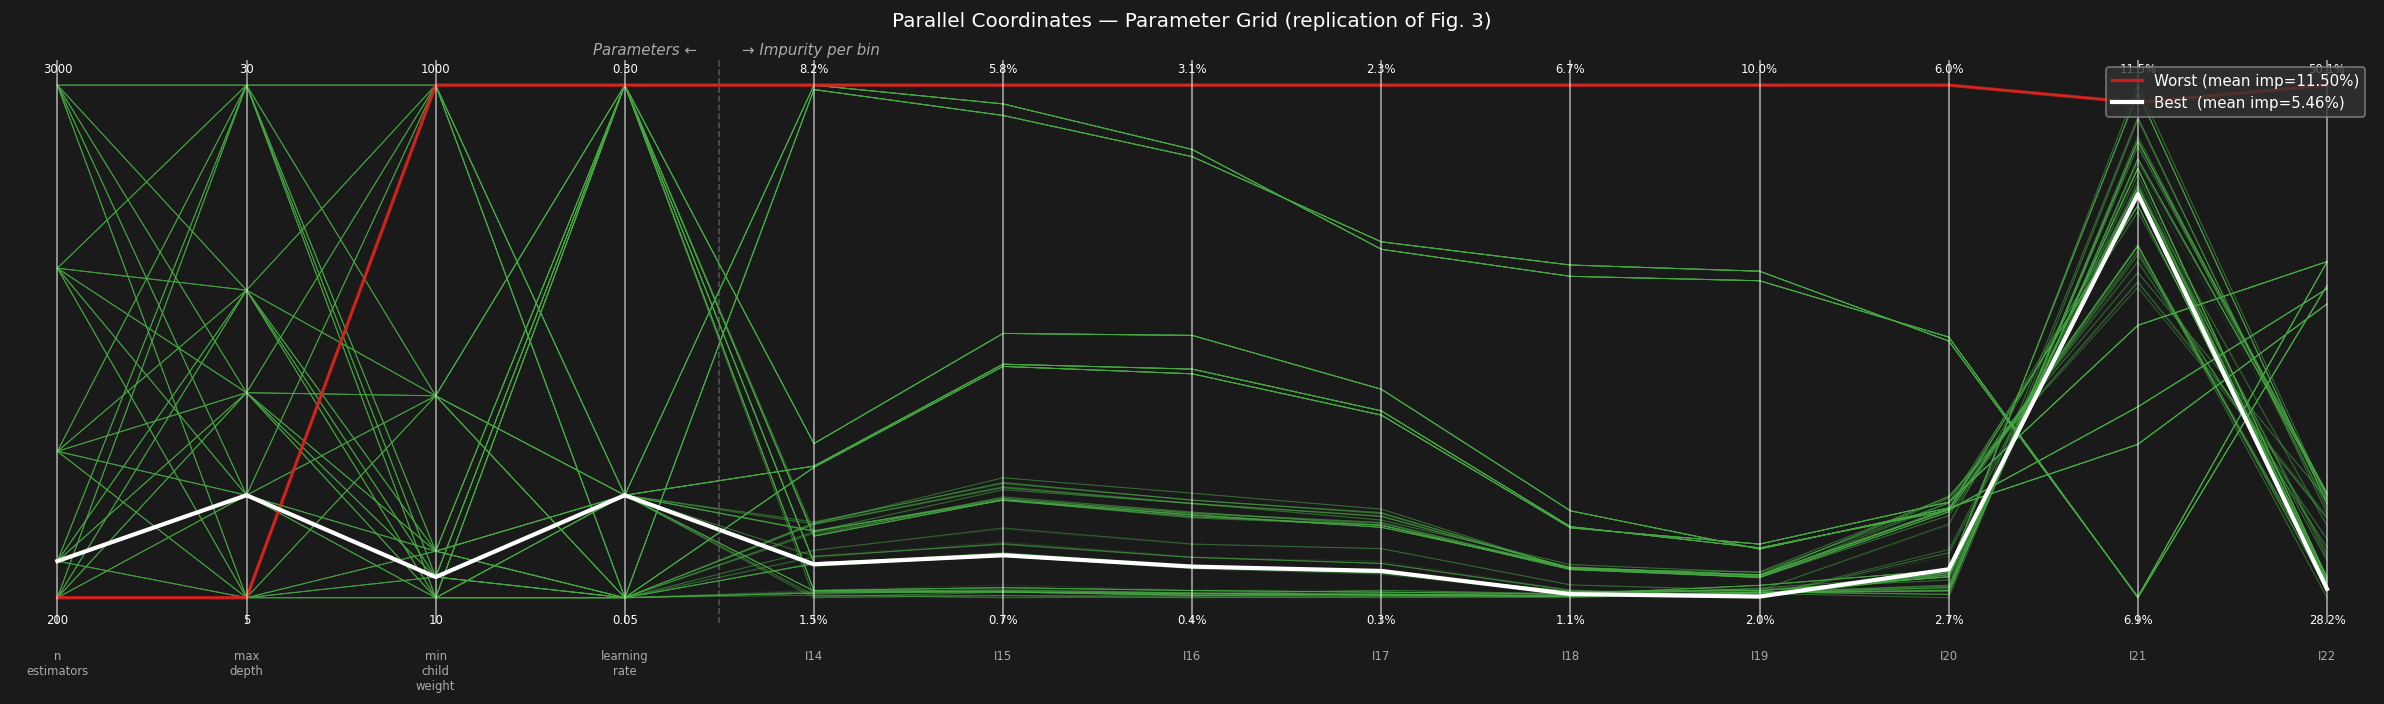

In [19]:
results_df = pd.DataFrame(grid_results)

# Expand per-bin impurity into individual columns
imp_cols  = [f"I{b}" for b in range(14, 23)]
imp_array = np.array(results_df["impurity_per_bin"].tolist())
for j, col in enumerate(imp_cols):
    results_df[col] = imp_array[:, j]

best_row  = results_df.loc[results_df["mean_impurity"].idxmin()]
worst_row = results_df.loc[results_df["mean_impurity"].idxmax()]

BEST_PARAMS = {
    "n_estimators"    : int(best_row["n_estimators"]),
    "max_depth"       : int(best_row["max_depth"]),
    "min_child_weight": int(best_row["min_child_weight"]),
    "learning_rate"   : float(best_row["learning_rate"]),
}
print("Best parameters:")
for k, v in BEST_PARAMS.items():
    print(f"  {k:22s}: {v}")
print(f"  {'mean_impurity':22s}: {best_row['mean_impurity']:.4f}%")

param_cols = ["n_estimators", "max_depth", "min_child_weight", "learning_rate"]
plot_cols  = param_cols + imp_cols
n_axes     = len(plot_cols)

mins   = results_df[plot_cols].min()
maxes  = results_df[plot_cols].max()
normed = (results_df[plot_cols] - mins) / (maxes - mins + 1e-12)

best_normed  = (best_row[plot_cols]  - mins) / (maxes - mins + 1e-12)
worst_normed = (worst_row[plot_cols] - mins) / (maxes - mins + 1e-12)

x_positions = np.linspace(0, 1, n_axes)

fig, ax = plt.subplots(figsize=(20, 6))
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.05, 1.05)
ax.set_facecolor("#1a1a1a")
fig.patch.set_facecolor("#1a1a1a")

for _, row in normed.iterrows():
    ax.plot(x_positions, [row[c] for c in plot_cols],
            color="#4daf4a", alpha=0.15, linewidth=0.6, zorder=1)

ax.plot(x_positions, [worst_normed[c] for c in plot_cols],
        color="#e41a1c", linewidth=2.0, alpha=0.85, zorder=2,
        label=f"Worst (mean imp={worst_row['mean_impurity']:.2f}%)")
ax.plot(x_positions, [best_normed[c] for c in plot_cols],
        color="white", linewidth=2.5, zorder=3,
        label=f"Best  (mean imp={best_row['mean_impurity']:.2f}%)")

for i, (x, col) in enumerate(zip(x_positions, plot_cols)):
    ax.axvline(x, color="white", linewidth=1.0, alpha=0.6, zorder=4)
    raw_min, raw_max = mins[col], maxes[col]
    if col in param_cols:
        fmt = lambda v: f"{v:.2f}" if col == "learning_rate" else f"{int(v)}"
    else:
        fmt = lambda v: f"{v:.1f}%"
    ax.text(x,  1.02, fmt(raw_max), ha="center", va="bottom", fontsize=7, color="white")
    ax.text(x, -0.03, fmt(raw_min), ha="center", va="top",    fontsize=7, color="white")
    ax.text(x, -0.10, col.replace("_", "\n"), ha="center", va="top",
            fontsize=7, color="#aaaaaa")

boundary_x = (x_positions[len(param_cols)-1] + x_positions[len(param_cols)]) / 2
ax.axvline(boundary_x, color="#888888", linewidth=1.0, linestyle="--", alpha=0.5, zorder=4)
ax.text(boundary_x - 0.01, 1.06, "Parameters ←",       ha="right", fontsize=9, color="#aaaaaa", style="italic")
ax.text(boundary_x + 0.01, 1.06, "→ Impurity per bin", ha="left",  fontsize=9, color="#aaaaaa", style="italic")

ax.set_title("Parallel Coordinates — Parameter Grid (replication of Fig. 3)",
             color="white", fontsize=12, pad=20)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc="upper right", fontsize=9, facecolor="#333333",
          edgecolor="#888888", labelcolor="white")
plt.tight_layout()
plt.savefig("figures/parallel_coordinates.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## Final Model Training
Train the optimized XGBoost classifier with decorrelated features and class balancing.

In [ ]:
final_model = XGBClassifier(
    **BEST_PARAMS,
    device="cuda",
    tree_method="hist",
    eval_metric="logloss",
    early_stopping_rounds=50,
    random_state=RANDOM_SEED,
)

t0 = time.time()
final_model.fit(
    X_train_fit, y_train,
    eval_set=[(X_eval_fit, y_eval)],   # eval set
    verbose=False
)
print(f"Final model trained in {time.time()-t0:.1f}s")

joblib.dump(final_model, "models/final_xgboost_model.pkl")
print("Model saved → models/final_xgboost_model.pkl")

Final model trained in 0.9s
Model saved → models/final_xgboost_model.pkl


## Ablation & Sensitivity Studies
Analyze model sensitivity to hyperparameters and sample sizes.

Parameter sensitivity values:
  n_estimators          : best=3000, worst=200
  max_depth             : best=5, worst=30
  min_child_weight      : best=50, worst=1000
  learning_rate         : best=0.1, worst=0.3


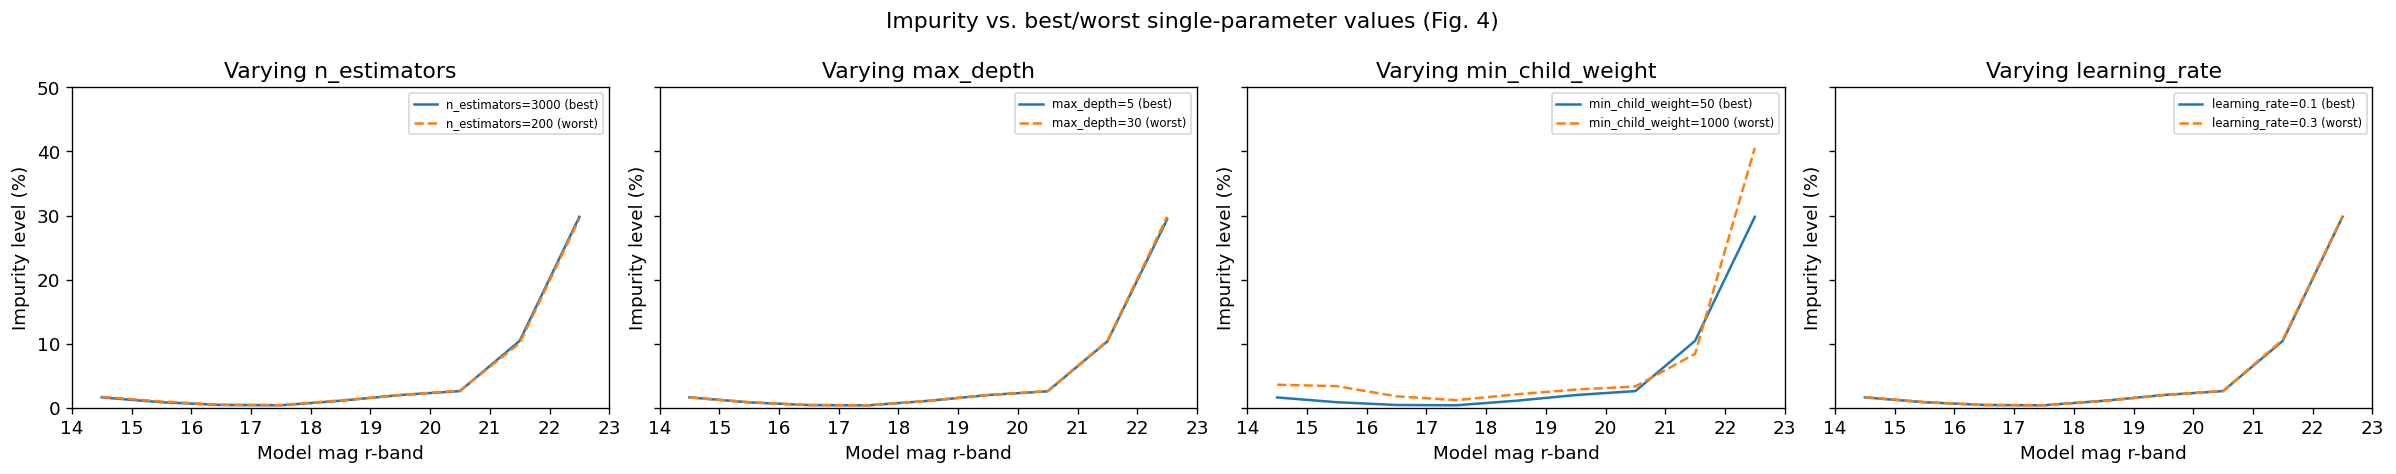

In [21]:
# Pick best/worst value per grid parameter
sensitivity_experiments = {}
for param in ["n_estimators", "max_depth", "min_child_weight", "learning_rate"]:
    perf = (
        results_df.groupby(param)["mean_impurity"]
        .mean()
        .sort_values()
    )
    sensitivity_experiments[param] = [perf.index[0], perf.index[-1]]

print("Parameter sensitivity values:")
for p, (bv, wv) in sensitivity_experiments.items():
    print(f"  {p:22s}: best={bv}, worst={wv}")

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
fig.suptitle("Impurity vs. best/worst single-parameter values (Fig. 4)")

for ax, (param, (best_val, worst_val)) in zip(axes, sensitivity_experiments.items()):
    for val, style, tag in [(best_val, "-", "best"), (worst_val, "--", "worst")]:
        params = {**BEST_PARAMS, param: val}
        m = XGBClassifier(
            **params, device="cuda", tree_method="hist",
            eval_metric="logloss", early_stopping_rounds=50,
            random_state=RANDOM_SEED,
        )
        m.fit(X_train_fit, y_train, eval_set=[(X_eval_fit, y_eval)], verbose=False)
        proba = m.predict_proba(X_eval_fit)[:, 1]
        _, imp = compute_efficiency_impurity(y_eval, proba, mag_eval)
        ax.plot(MAG_BIN_CENTERS, imp, linestyle=style,
                label=f"{param}={val} ({tag})")
    ax.set_xlabel("Model mag r-band")
    ax.set_ylabel("Impurity level (%)")
    ax.set_title(f"Varying {param}")
    ax.legend(fontsize=7)
    ax.set_xlim(14, 23)
    ax.set_ylim(0, 50)

plt.tight_layout()
plt.savefig("figures/single_param_sensitivity.png")
plt.show()

In [22]:
GALAXY_SIZES = [3_000, 10_000, 30_000, 100_000]
STAR_SIZES   = [500, 3_000, 6_000, 12_000]

size_results = {}
size_times   = {}

for n_gal in GALAXY_SIZES:
    for n_star in STAR_SIZES:
        key = (n_gal, n_star)
        try:
            X_tr, y_tr, mag_tr = subsample_training(
                X_trainpool_only, y_trainpool_only, mag_train_pool_only,
                n_gal, n_star
            )
        except ValueError as e:
            print(f"  Skipping {key}: {e}")
            continue

        # Refit decorrelator on this specific training subsample
        dec_sub    = FeatureDecorrelator()
        X_tr_fit   = dec_sub.fit_transform(X_tr)
        X_ev_fit   = dec_sub.transform(X_eval)

        t0 = time.time()
        m = XGBClassifier(
            **BEST_PARAMS, device="cuda", tree_method="hist",
            eval_metric="logloss", early_stopping_rounds=50,
            random_state=RANDOM_SEED,
        )
        m.fit(X_tr_fit, y_tr, eval_set=[(X_ev_fit, y_eval)], verbose=False)
        elapsed = time.time() - t0

        proba = m.predict_proba(X_ev_fit)[:, 1]
        _, imp = compute_efficiency_impurity(y_eval, proba, mag_eval)
        size_results[key] = imp
        size_times[key]   = elapsed
        print(f"  n_gal={n_gal:>7,}, n_star={n_star:>6,}  "
              f"→  mean_imp={np.nanmean(imp):.3f}%  ({elapsed:.1f}s)")

print("\nTraining time table (seconds):")
time_table = pd.DataFrame(
    index=[f"{s} stars" for s in STAR_SIZES],
    columns=[f"{g} galaxies" for g in GALAXY_SIZES]
)
for (ng, ns), t in size_times.items():
    time_table.loc[f"{ns} stars", f"{ng} galaxies"] = round(t, 1)
print(time_table.to_string())

  n_gal=  3,000, n_star=   500  →  mean_imp=7.799%  (0.6s)
  n_gal=  3,000, n_star= 3,000  →  mean_imp=3.480%  (0.8s)
  n_gal=  3,000, n_star= 6,000  →  mean_imp=2.502%  (0.8s)
  n_gal=  3,000, n_star=12,000  →  mean_imp=2.035%  (0.8s)
  n_gal= 10,000, n_star=   500  →  mean_imp=11.714%  (0.7s)
  n_gal= 10,000, n_star= 3,000  →  mean_imp=4.807%  (0.8s)
  n_gal= 10,000, n_star= 6,000  →  mean_imp=3.439%  (0.8s)
  n_gal= 10,000, n_star=12,000  →  mean_imp=2.564%  (0.8s)
  n_gal= 30,000, n_star=   500  →  mean_imp=15.672%  (0.7s)
  n_gal= 30,000, n_star= 3,000  →  mean_imp=7.368%  (0.8s)
  n_gal= 30,000, n_star= 6,000  →  mean_imp=5.456%  (0.8s)
  n_gal= 30,000, n_star=12,000  →  mean_imp=3.596%  (0.9s)
  n_gal=100,000, n_star=   500  →  mean_imp=23.968%  (0.7s)
  n_gal=100,000, n_star= 3,000  →  mean_imp=10.788%  (1.0s)
  n_gal=100,000, n_star= 6,000  →  mean_imp=8.391%  (1.0s)
  n_gal=100,000, n_star=12,000  →  mean_imp=6.494%  (1.2s)

Training time table (seconds):
            3000 gal

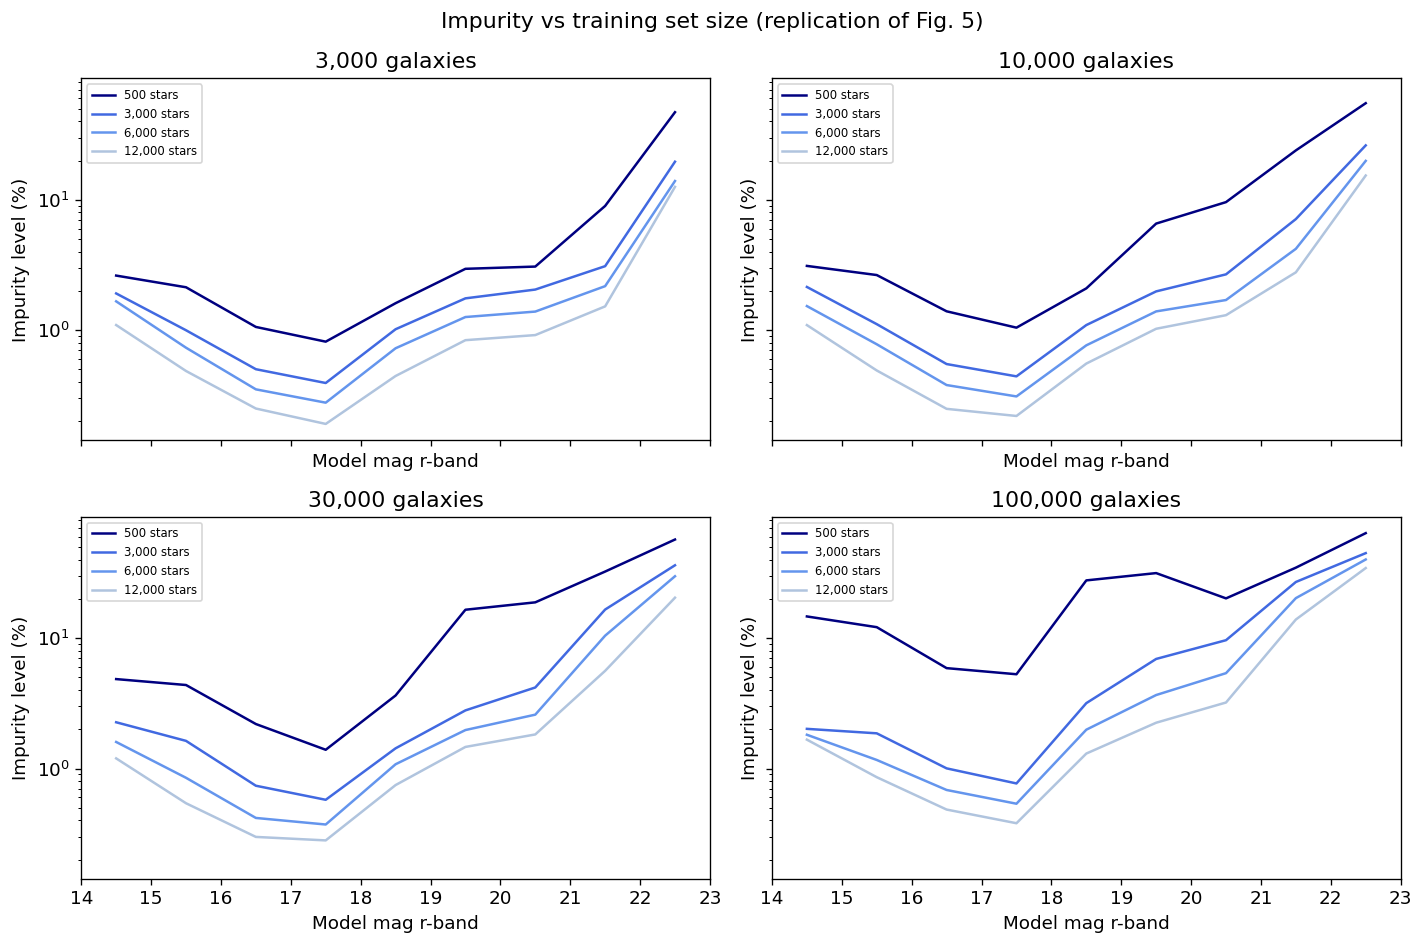

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True, sharex=True)
fig.suptitle("Impurity vs training set size (replication of Fig. 5)")
colors_size = ["navy", "royalblue", "cornflowerblue", "lightsteelblue"]

for ax, n_gal in zip(axes.flat, GALAXY_SIZES):
    for color, n_star in zip(colors_size, STAR_SIZES):
        key = (n_gal, n_star)
        if key not in size_results:
            continue
        ax.semilogy(MAG_BIN_CENTERS, size_results[key],
                    label=f"{n_star:,} stars", color=color)
    ax.set_title(f"{n_gal:,} galaxies")
    ax.set_xlabel("Model mag r-band")
    ax.set_ylabel("Impurity level (%)")
    ax.set_xlim(14, 23)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("figures/training_size_sensitivity.png")
plt.show()

### Depth Limit Analysis

  Depth < 19.5      : mean_imp=4.462%
  Depth < 20.5      : mean_imp=4.927%
  Depth < 21.5      : mean_imp=4.592%
  Depth Full depth  : mean_imp=4.973%


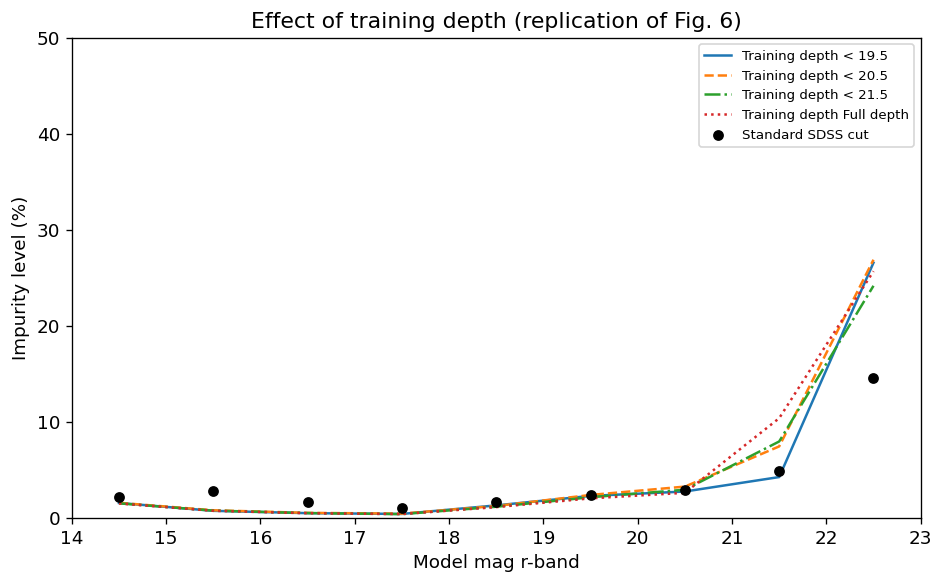

In [24]:
DEPTH_LIMITS = [19.5, 20.5, 21.5, None]
DEPTH_LABELS = ["< 19.5", "< 20.5", "< 21.5", "Full depth"]

depth_results = {}

for limit, label in zip(DEPTH_LIMITS, DEPTH_LABELS):
    mask = (mag_train_pool_only < limit) if limit is not None            else np.ones(len(mag_train_pool_only), dtype=bool)

    X_pool_d   = X_trainpool_only[mask]
    y_pool_d   = y_trainpool_only[mask]
    mag_pool_d = mag_train_pool_only[mask]

    n_gal_use  = min(N_GAL_DEFAULT,  (y_pool_d == 1).sum())
    n_star_use = min(N_STAR_DEFAULT, (y_pool_d == 0).sum())

    X_tr, y_tr, _ = subsample_training(
        X_pool_d, y_pool_d, mag_pool_d, n_gal_use, n_star_use
    )

    # Decorrelator per depth subset
    dec_depth  = FeatureDecorrelator()
    X_tr_fit   = dec_depth.fit_transform(X_tr)
    X_te_fit   = dec_depth.transform(X_test)     # eval against test split

    X_ev_depth = dec_depth.transform(X_eval)

    m = XGBClassifier(
        **BEST_PARAMS, device="cuda", tree_method="hist",
        eval_metric="logloss", early_stopping_rounds=50,
        random_state=RANDOM_SEED,
    )
    m.fit(X_tr_fit, y_tr, eval_set=[(X_ev_depth, y_eval)], verbose=False)

    proba = m.predict_proba(X_te_fit)[:, 1]
    _, imp = compute_efficiency_impurity(y_test, proba, mag_test)
    depth_results[label] = imp
    print(f"  Depth {label:12s}: mean_imp={np.nanmean(imp):.3f}%")

fig, ax = plt.subplots(figsize=(8, 5))
for (label, imp), style in zip(depth_results.items(), ["-", "--", "-.", ":"]):
    ax.plot(MAG_BIN_CENTERS, imp, linestyle=style, label=f"Training depth {label}")

sdss_eff, sdss_imp = sdss_baseline_efficiency_impurity(y_test, tp_test, mag_test)
ax.scatter(MAG_BIN_CENTERS, sdss_imp, marker="o", color="black",
           zorder=5, label="Standard SDSS cut", s=30)

ax.set_xlabel("Model mag r-band")
ax.set_ylabel("Impurity level (%)")
ax.set_title("Effect of training depth (replication of Fig. 6)")
ax.set_xlim(14, 23)
ax.set_ylim(0, 50)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/training_depth_sensitivity.png")
plt.show()

### Feature Importance and Ablation

  Shapes only                 : mean_imp=10.473%
  Shape + concentration       : mean_imp=7.164%
  Shapes + magnitudes         : mean_imp=5.103%
  Colors + magnitudes         : mean_imp=5.241%
  All features                : mean_imp=4.973%


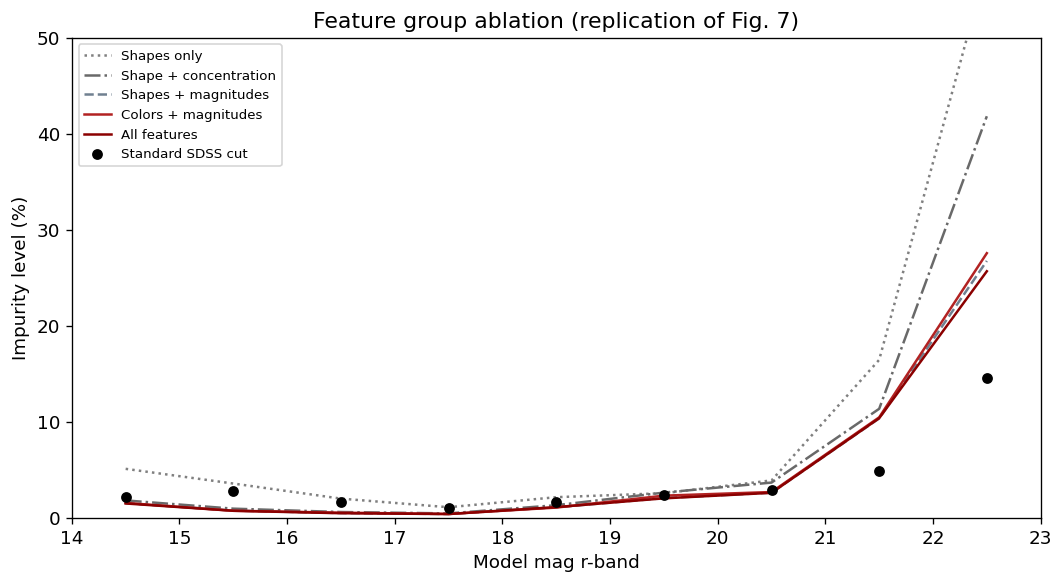

In [25]:
FEATURE_SETS = {
    "Shapes only"         : SHAPE_FEATURES,
    "Shape + concentration": SHAPE_FEATURES + CONCENTRATION_FEATURE,
    "Shapes + magnitudes" : SHAPE_FEATURES + MAG_FEATURES,
    "Colors + magnitudes" : COLOR_FEATURES + MAG_FEATURES,
    "All features"        : ALL_FEATURES,
}

ablation_results = {}

for feat_label, feat_cols in FEATURE_SETS.items():
    # Build column index into ALL_FEATURES (the master array)
    col_idx = [ALL_FEATURES.index(c) for c in feat_cols if c in ALL_FEATURES]

    X_tr_sub = X_train_fit[:, col_idx]
    X_te_sub = X_test_fit[:,  col_idx]
    X_ev_sub = X_eval_fit[:,  col_idx]

    m = XGBClassifier(
        **BEST_PARAMS, device="cuda", tree_method="hist",
        eval_metric="logloss", early_stopping_rounds=50,
        random_state=RANDOM_SEED,
    )
    m.fit(X_tr_sub, y_train, eval_set=[(X_ev_sub, y_eval)], verbose=False)
    proba = m.predict_proba(X_te_sub)[:, 1]
    _, imp = compute_efficiency_impurity(y_test, proba, mag_test)
    ablation_results[feat_label] = imp
    print(f"  {feat_label:28s}: mean_imp={np.nanmean(imp):.3f}%")

fig, ax = plt.subplots(figsize=(9, 5))
styles_abl  = [":", "-.", "--", "-", "-"]
colors_abl  = ["grey", "dimgrey", "slategrey", "firebrick", "darkred"]

for (label, imp), style, color in zip(ablation_results.items(), styles_abl, colors_abl):
    ax.plot(MAG_BIN_CENTERS, imp, linestyle=style, color=color,
            label=label, linewidth=1.5)

ax.scatter(MAG_BIN_CENTERS, sdss_imp, marker="o", color="black",
           zorder=5, label="Standard SDSS cut", s=30)

ax.set_xlabel("Model mag r-band")
ax.set_ylabel("Impurity level (%)")
ax.set_title("Feature group ablation (replication of Fig. 7)")
ax.set_xlim(14, 23)
ax.set_ylim(0, 50)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/feature_ablation.png")
plt.show()

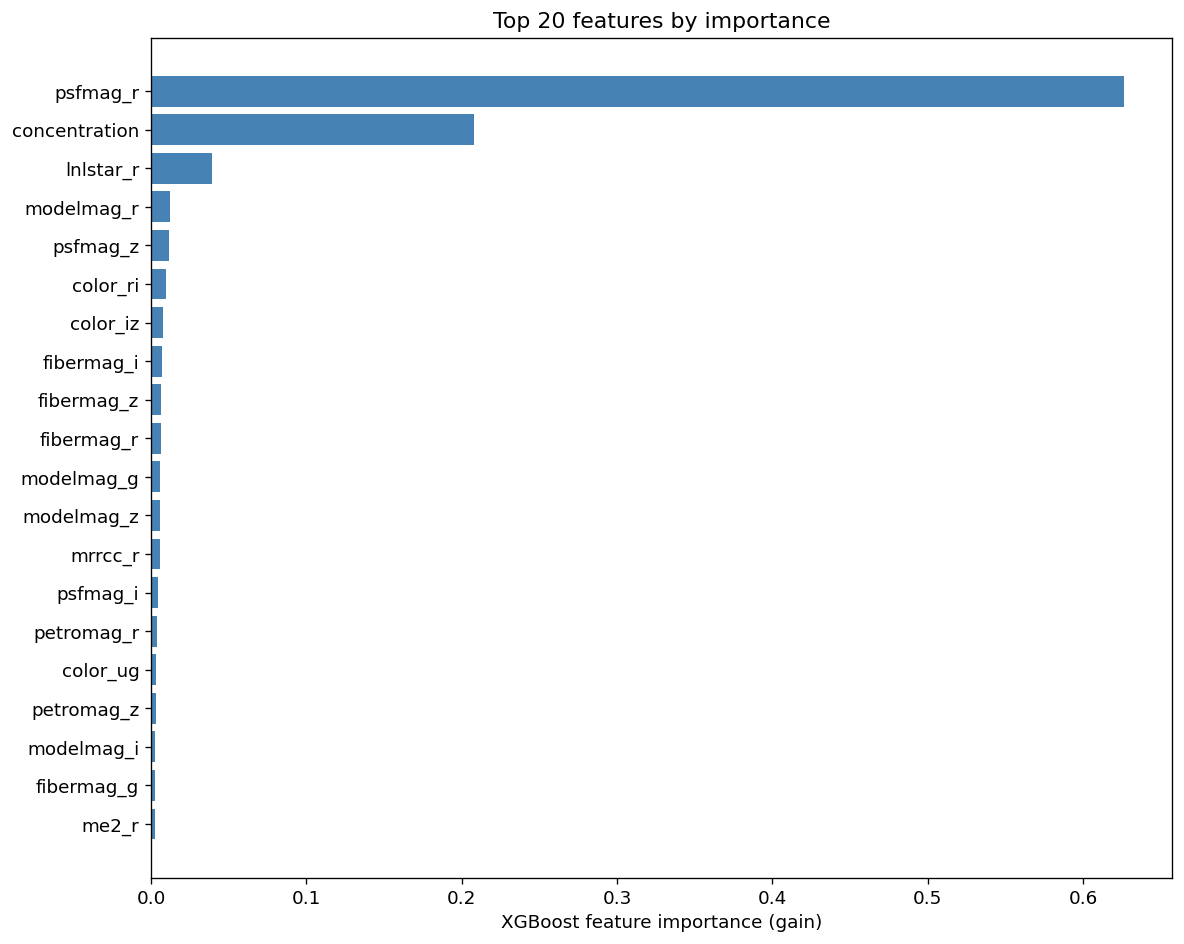


Top 10 features:
      feature  importance
     psfmag_r    0.626233
concentration    0.207782
    lnlstar_r    0.039488
   modelmag_r    0.012186
     psfmag_z    0.011372
     color_ri    0.009545
     color_iz    0.007553
   fibermag_i    0.006982
   fibermag_z    0.006319
   fibermag_r    0.006202


In [26]:
importance   = final_model.feature_importances_
feat_imp_df  = pd.DataFrame({
    "feature"   : ALL_FEATURES,
    "importance": importance,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp_df["feature"][:20][::-1],
        feat_imp_df["importance"][:20][::-1],
        color="steelblue")
ax.set_xlabel("XGBoost feature importance (gain)")
ax.set_title("Top 20 features by importance")
plt.tight_layout()
plt.savefig("figures/feature_importance.png")
plt.show()

print("\nTop 10 features:")
print(feat_imp_df.head(10).to_string(index=False))

## Performance Evaluation
### Global ROC Curve

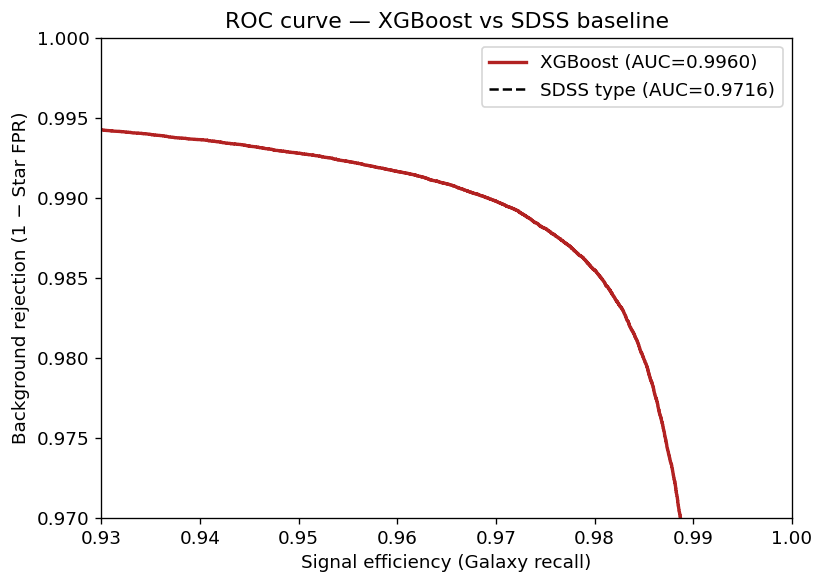

In [27]:
from sklearn.metrics import roc_curve, auc

proba_test  = final_model.predict_proba(X_test_fit)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, proba_test)
auc_xgb              = auc(fpr_xgb, tpr_xgb)

fpr_sdss, tpr_sdss, _ = roc_curve(y_test, tp_test.astype(float))
auc_sdss               = auc(fpr_sdss, tpr_sdss)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(tpr_xgb,  1 - fpr_xgb,
        label=f"XGBoost (AUC={auc_xgb:.4f})", color="firebrick", linewidth=2)
ax.plot(tpr_sdss, 1 - fpr_sdss,
        label=f"SDSS type (AUC={auc_sdss:.4f})", color="black",
        linewidth=1.5, linestyle="--")
ax.set_xlabel("Signal efficiency (Galaxy recall)")
ax.set_ylabel("Background rejection (1 − Star FPR)")
ax.set_title("ROC curve — XGBoost vs SDSS baseline")
ax.set_xlim(0.93, 1.0)
ax.set_ylim(0.97, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig("figures/roc_curve.png")
plt.show()

### Baseline Comparison
Compare XGBoost impurity against the legacy SDSS photometric pipeline.

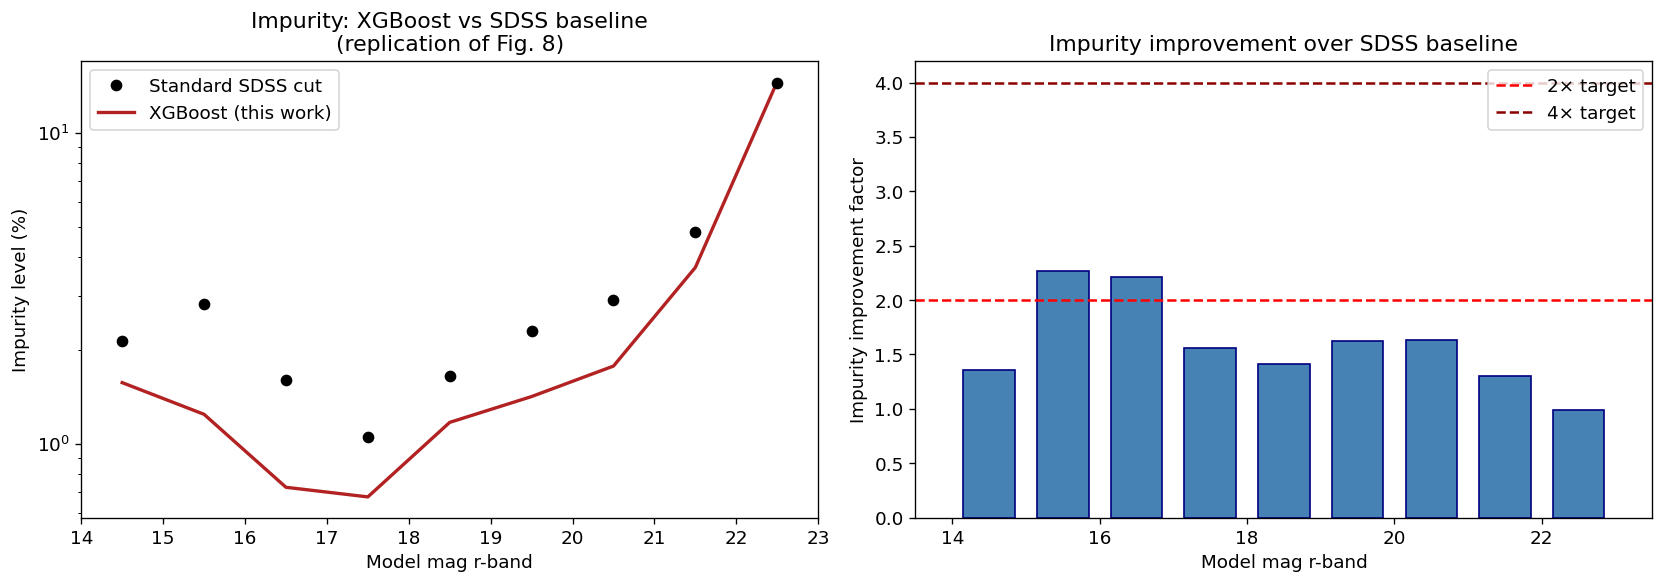


Per-bin summary:
 mag_bin  sdss_imp_%  xgb_imp_%  improvement_x
    14.5       2.139      1.575           1.36
    15.5       2.821      1.246           2.26
    16.5       1.607      0.726           2.21
    17.5       1.055      0.676           1.56
    18.5       1.658      1.174           1.41
    19.5       2.313      1.421           1.63
    20.5       2.900      1.780           1.63
    21.5       4.818      3.694           1.30
    22.5      14.504     14.613           0.99

Overall mean improvement : 1.60×
Paper target             : 2–4×


In [28]:
sdss_eff_test, sdss_imp_test = sdss_baseline_efficiency_impurity(
    y_test, tp_test, mag_test
)

proba_test      = final_model.predict_proba(X_test_fit)[:, 1]
xgb_imp_matched = find_threshold_at_target_efficiency(
    y_test, proba_test, mag_test,
    target_efficiency_per_bin=sdss_eff_test
)
improvement = sdss_imp_test / xgb_imp_matched

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogy(MAG_BIN_CENTERS, sdss_imp_test,
                 marker="o", color="black", linestyle="none",
                 label="Standard SDSS cut", zorder=5)
axes[0].semilogy(MAG_BIN_CENTERS, xgb_imp_matched,
                 color="firebrick", linewidth=2, label="XGBoost (this work)")
axes[0].set_xlabel("Model mag r-band")
axes[0].set_ylabel("Impurity level (%)")
axes[0].set_title("Impurity: XGBoost vs SDSS baseline\n(replication of Fig. 8)")
axes[0].set_xlim(14, 23)
axes[0].legend()

axes[1].bar(MAG_BIN_CENTERS, improvement, width=0.7,
            color="steelblue", edgecolor="navy")
axes[1].axhline(2, color="red",     linestyle="--", label="2× target")
axes[1].axhline(4, color="darkred", linestyle="--", label="4× target")
axes[1].set_xlabel("Model mag r-band")
axes[1].set_ylabel("Impurity improvement factor")
axes[1].set_title("Impurity improvement over SDSS baseline")
axes[1].set_xlim(13.5, 23.5)
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/final_evaluation.png")
plt.show()

summary = pd.DataFrame({
    "mag_bin"       : MAG_BIN_CENTERS,
    "sdss_imp_%"    : np.round(sdss_imp_test,    3),
    "xgb_imp_%"     : np.round(xgb_imp_matched,  3),
    "improvement_x" : np.round(improvement,       2),
})
print("\nPer-bin summary:")
print(summary.to_string(index=False))
summary.to_csv("results/final_comparison.csv", index=False)
print(f"\nOverall mean improvement : {np.nanmean(improvement):.2f}×")
print(f"Paper target             : 2–4×")

### Generalization Checks

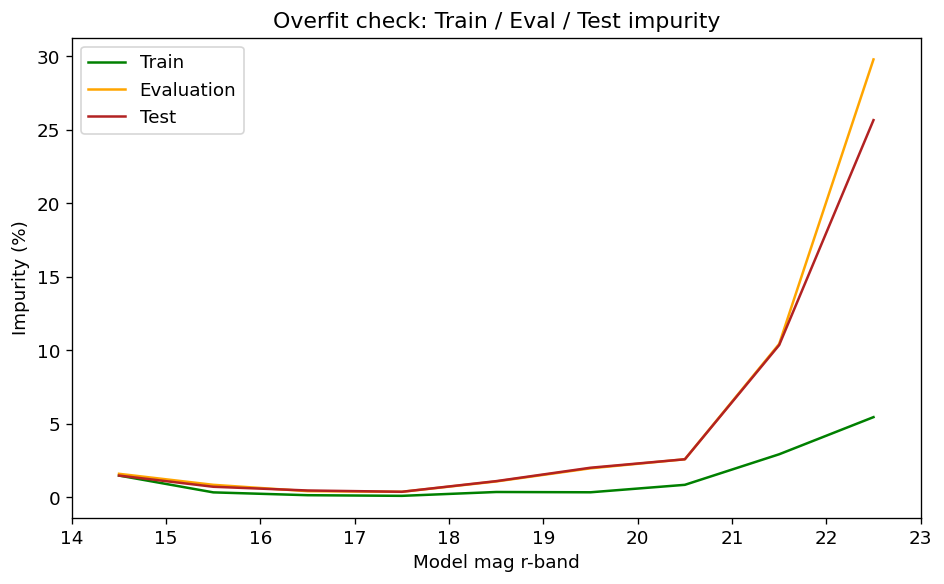

If train impurity is substantially lower than test → overfitting.
Mean impurity — Train: 1.332%  Eval: 5.456%  Test: 4.973%


In [29]:
proba_train = final_model.predict_proba(X_train_fit)[:, 1]
proba_eval2 = final_model.predict_proba(X_eval_fit)[:, 1]
proba_test2 = final_model.predict_proba(X_test_fit)[:, 1]

_, imp_train = compute_efficiency_impurity(y_train, proba_train, mag_train)
_, imp_eval2 = compute_efficiency_impurity(y_eval,  proba_eval2, mag_eval)
_, imp_test2 = compute_efficiency_impurity(y_test,  proba_test2, mag_test)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(MAG_BIN_CENTERS, imp_train, label="Train",      color="green",     linewidth=1.5)
ax.plot(MAG_BIN_CENTERS, imp_eval2, label="Evaluation", color="orange",    linewidth=1.5)
ax.plot(MAG_BIN_CENTERS, imp_test2, label="Test",       color="firebrick", linewidth=1.5)
ax.set_xlabel("Model mag r-band")
ax.set_ylabel("Impurity (%)")
ax.set_title("Overfit check: Train / Eval / Test impurity")
ax.legend()
ax.set_xlim(14, 23)
plt.tight_layout()
plt.savefig("figures/overfit_check.png")
plt.show()

print("If train impurity is substantially lower than test → overfitting.")
print(f"Mean impurity — Train: {np.nanmean(imp_train):.3f}%  "
      f"Eval: {np.nanmean(imp_eval2):.3f}%  "
      f"Test: {np.nanmean(imp_test2):.3f}%")

### Impact of Feature Decorrelation

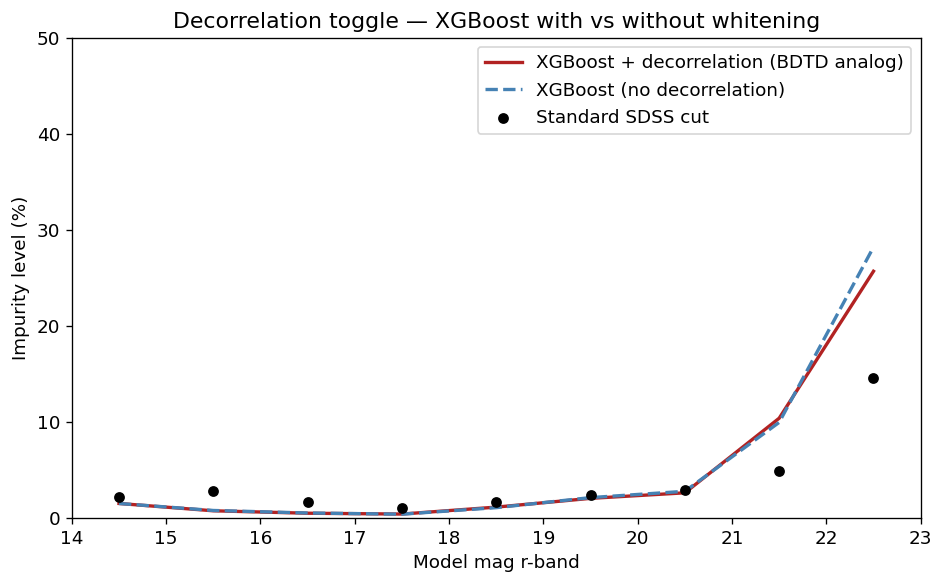

Mean impurity WITH    decorrelation : 4.973%
Mean impurity WITHOUT decorrelation : 5.229%
Δ impurity (decorrelation benefit)  : +0.256%


In [30]:
# Variant A: with decorrelation (already trained as final_model)
proba_with_dec = final_model.predict_proba(X_test_fit)[:, 1]
_, imp_with_dec = compute_efficiency_impurity(y_test, proba_with_dec, mag_test)

# Variant B: without decorrelation (raw features)
model_no_dec = XGBClassifier(
    **BEST_PARAMS, device="cuda", tree_method="hist",
    eval_metric="logloss", early_stopping_rounds=50,
    random_state=RANDOM_SEED,
)
model_no_dec.fit(X_train, y_train, eval_set=[(X_eval, y_eval)], verbose=False)
proba_no_dec = model_no_dec.predict_proba(X_test)[:, 1]
_, imp_no_dec = compute_efficiency_impurity(y_test, proba_no_dec, mag_test)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(MAG_BIN_CENTERS, imp_with_dec,
        color="firebrick", linewidth=2,   label="XGBoost + decorrelation (BDTD analog)")
ax.plot(MAG_BIN_CENTERS, imp_no_dec,
        color="steelblue", linewidth=2, linestyle="--", label="XGBoost (no decorrelation)")
ax.scatter(MAG_BIN_CENTERS, sdss_imp, marker="o", color="black",
           zorder=5, label="Standard SDSS cut", s=30)
ax.set_xlabel("Model mag r-band")
ax.set_ylabel("Impurity level (%)")
ax.set_title("Decorrelation toggle — XGBoost with vs without whitening")
ax.set_xlim(14, 23)
ax.set_ylim(0, 50)
ax.legend()
plt.tight_layout()
plt.savefig("figures/decorrelation_toggle.png")
plt.show()

delta = np.nanmean(imp_no_dec) - np.nanmean(imp_with_dec)
print(f"Mean impurity WITH    decorrelation : {np.nanmean(imp_with_dec):.3f}%")
print(f"Mean impurity WITHOUT decorrelation : {np.nanmean(imp_no_dec):.3f}%")
print(f"Δ impurity (decorrelation benefit)  : {delta:+.3f}%")

### Calibration Assessment

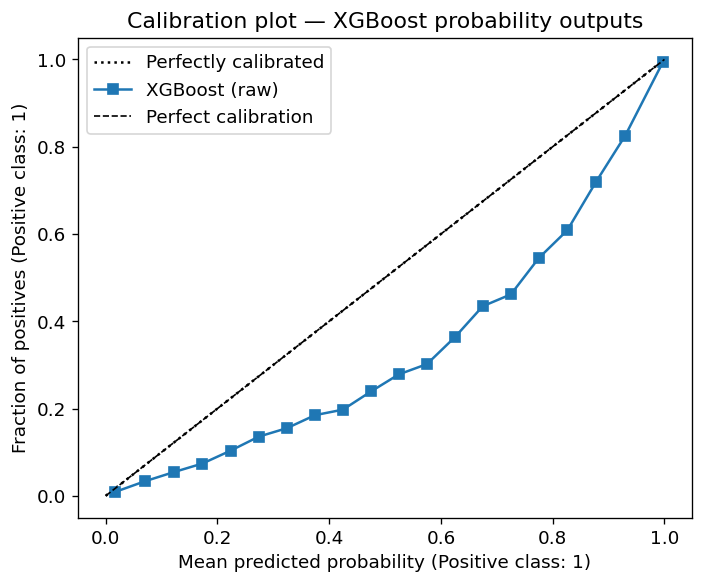

Deviation from the diagonal indicates miscalibration.
Consider sklearn.calibration.CalibratedClassifierCV for production use.


In [31]:
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(6, 5))
CalibrationDisplay.from_predictions(
    y_test, proba_test,
    n_bins=20, ax=ax, name="XGBoost (raw)"
)
ax.set_title("Calibration plot — XGBoost probability outputs")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ax.legend()
plt.tight_layout()
plt.savefig("figures/calibration_plot.png")
plt.show()

print("Deviation from the diagonal indicates miscalibration.")
print("Consider sklearn.calibration.CalibratedClassifierCV for production use.")

### Magnitude-Stratified ROC

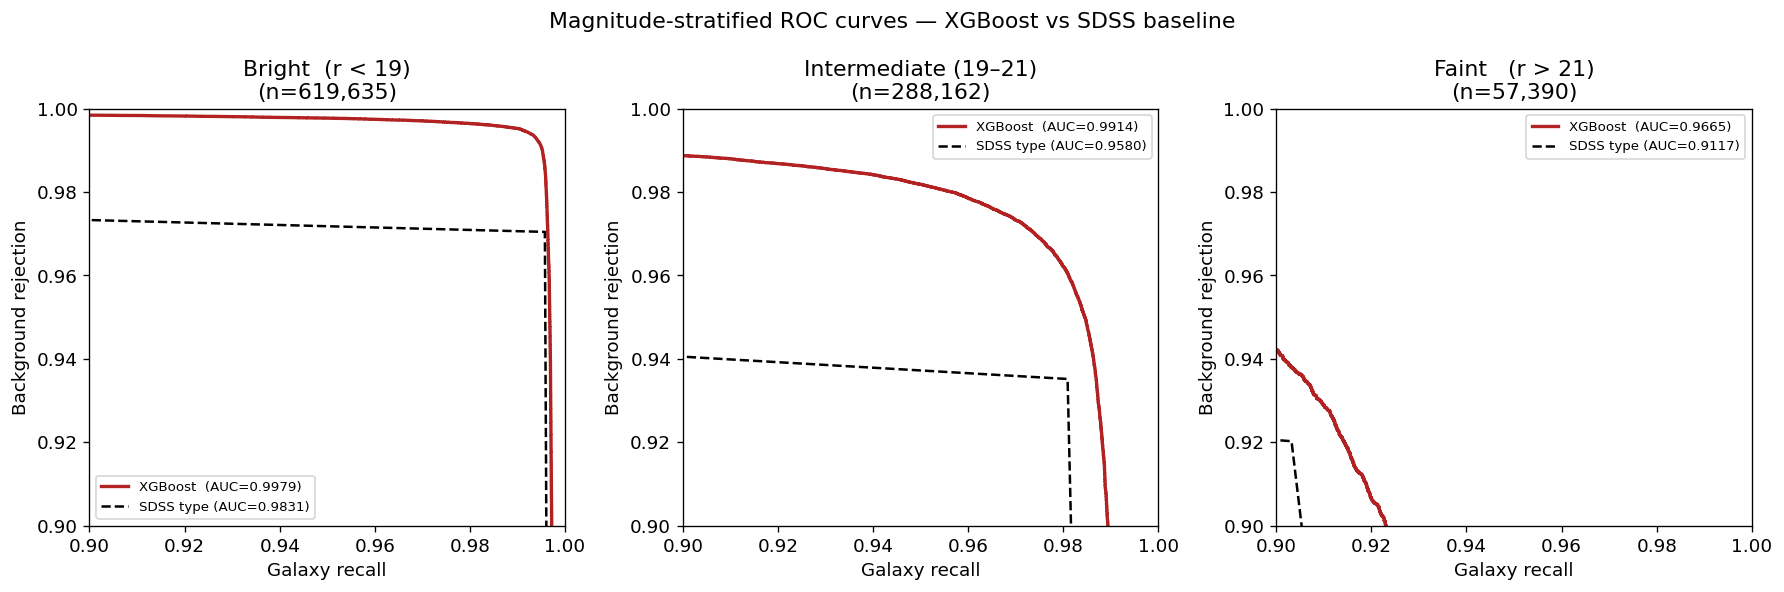

In [32]:
from sklearn.metrics import roc_curve, auc

MAG_REGIMES = {
    "Bright  (r < 19)"     : (14, 19),
    "Intermediate (19–21)" : (19, 21),
    "Faint   (r > 21)"     : (21, 23),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Magnitude-stratified ROC curves — XGBoost vs SDSS baseline")

for ax, (regime_label, (lo, hi)) in zip(axes, MAG_REGIMES.items()):
    mask = (mag_test >= lo) & (mag_test < hi)
    if mask.sum() < 10:
        ax.set_title(f"{regime_label}\n(insufficient data)")
        continue

    yt  = y_test[mask]
    pt  = proba_test[mask]
    sdt = tp_test[mask].astype(float)

    fpr_x, tpr_x, _ = roc_curve(yt, pt)
    fpr_s, tpr_s, _ = roc_curve(yt, sdt)
    auc_x = auc(fpr_x, tpr_x)
    auc_s = auc(fpr_s, tpr_s)

    ax.plot(tpr_x, 1 - fpr_x, color="firebrick", linewidth=2,
            label=f"XGBoost  (AUC={auc_x:.4f})")
    ax.plot(tpr_s, 1 - fpr_s, color="black", linewidth=1.5, linestyle="--",
            label=f"SDSS type (AUC={auc_s:.4f})")
    ax.set_xlabel("Galaxy recall")
    ax.set_ylabel("Background rejection")
    ax.set_title(f"{regime_label}\n(n={mask.sum():,})")
    ax.set_xlim(0.9, 1.0)
    ax.set_ylim(0.9, 1.0)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("figures/roc_magnitude_stratified.png")
plt.show()

## SHAP Analysis
Calculate partial dependence and feature importance values using TreeExplainer on a test subset to avoid memory bottlenecks.

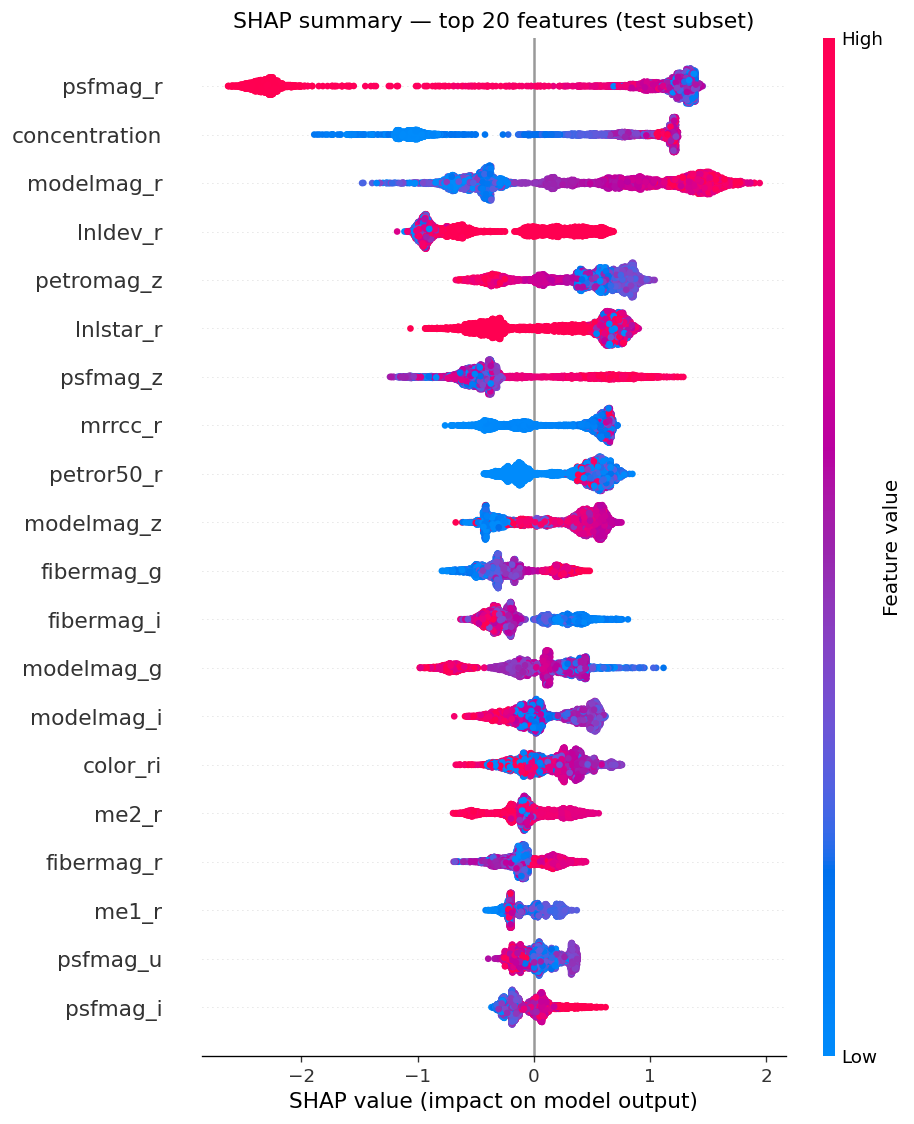

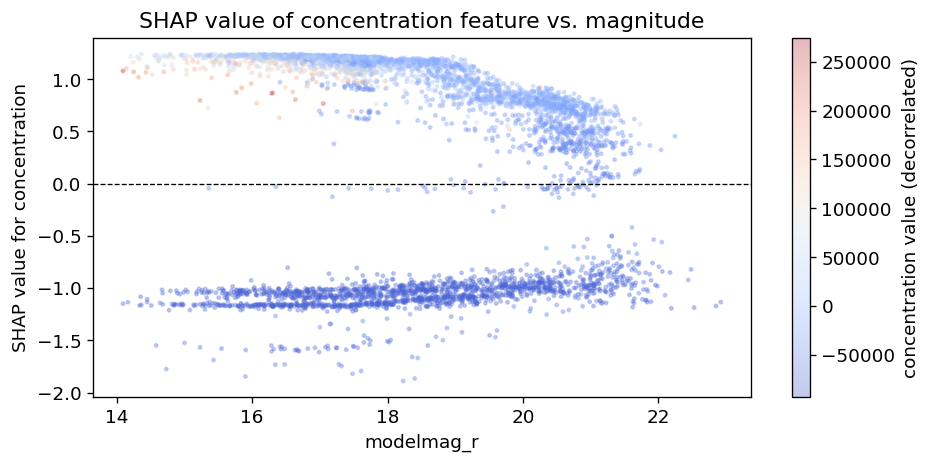

In [ ]:
# Subsample test set for SHAP to avoid memory overhead

N_SHAP = 5_000
rng_shap = np.random.default_rng(RANDOM_SEED)
shap_idx  = rng_shap.choice(len(X_test_fit), size=N_SHAP, replace=False)

import shap.explainers._tree as shap_tree
orig_decode = shap_tree.decode_ubjson_buffer
def new_decode(*args, **kwargs):
    jmodel = orig_decode(*args, **kwargs)
    try:
        base_score = jmodel["learner"]["learner_model_param"]["base_score"]
        if isinstance(base_score, str) and base_score.startswith('[') and base_score.endswith(']'):
            jmodel["learner"]["learner_model_param"]["base_score"] = base_score.strip('[]')
    except Exception:
        pass
    return jmodel
shap_tree.decode_ubjson_buffer = new_decode

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_fit[shap_idx])

# Summary beeswarm plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test_fit[shap_idx],
    feature_names=ALL_FEATURES,
    max_display=20, show=False
)
plt.title("SHAP summary — top 20 features (test subset)")
plt.tight_layout()
plt.savefig("figures/shap_summary.png", bbox_inches="tight")
plt.show()

# Magnitude-sliced SHAP for concentration
conc_idx = ALL_FEATURES.index("concentration")
mag_shap  = mag_test[shap_idx]
conc_shap = shap_values[:, conc_idx]

fig, ax = plt.subplots(figsize=(8, 4))
sc = ax.scatter(mag_shap, conc_shap, c=X_test_fit[shap_idx, conc_idx],
                cmap="coolwarm", alpha=0.3, s=4)
plt.colorbar(sc, ax=ax, label="concentration value (decorrelated)")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("modelmag_r")
ax.set_ylabel("SHAP value for concentration")
ax.set_title("SHAP value of concentration feature vs. magnitude")
plt.tight_layout()
plt.savefig("figures/shap_concentration_vs_mag.png")
plt.show()

### Selection Bias Documentation

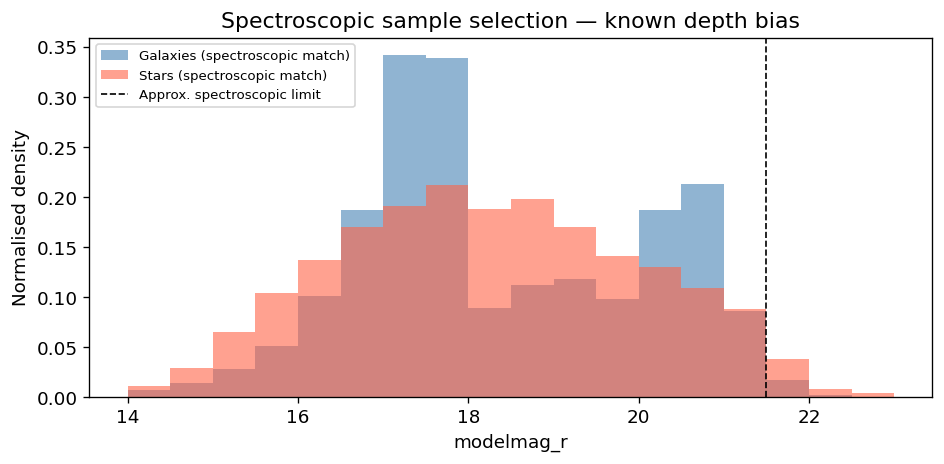

NOTE: spectroscopic completeness drops sharply beyond r~21.5.
Performance at faint magnitudes should be interpreted with caution.


In [34]:
# Document selection bias in training signal
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df.loc[df["label"]==1, "modelmag_r"], bins=np.arange(14, 23.5, 0.5),
        density=True, alpha=0.6, label="Galaxies (spectroscopic match)",
        histtype="stepfilled", color="steelblue")
ax.hist(df.loc[df["label"]==0, "modelmag_r"], bins=np.arange(14, 23.5, 0.5),
        density=True, alpha=0.6, label="Stars (spectroscopic match)",
        histtype="stepfilled", color="tomato")
ax.set_xlabel("modelmag_r")
ax.set_ylabel("Normalised density")
ax.set_title("Spectroscopic sample selection — known depth bias")
ax.axvline(21.5, color="black", linestyle="--", linewidth=1,
           label="Approx. spectroscopic limit")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/selection_bias.png")
plt.show()

print("NOTE: spectroscopic completeness drops sharply beyond r~21.5.")
print("Performance at faint magnitudes should be interpreted with caution.")